# Praktikum Machine Learning: Bab 2
## Workflow Machine Learning, CRISP-DM, dan Diagnosis Bias-Variance

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

*Notebook ini saya kerjakan di Google Colab / Jupyter Notebook.*

## Ringkasan Konsep

- **CRISP-DM**: kerangka baku proyek ML dengan 6 fase iteratif: 1) Business Understanding, 2) Data Understanding, 3) Data Preparation, 4) Modeling, 5) Evaluation, 6) Deployment.
- **Train/validation/test split**: train melatih model, validation memilih dan men-tuning model, test menilai hasil akhir tanpa pernah dipakai memilih model.
- **Stratified sampling**: pembagian data yang menjaga proporsi tiap kelas di setiap belahan, penting untuk dataset yang tidak seimbang.
- **Bias-variance tradeoff**: bias tinggi berarti model terlalu sederhana (underfitting), variance tinggi berarti model menghafal noise data latih (overfitting). Model ideal menyeimbangkan keduanya.
- **Learning curve**: plot skor train vs validasi terhadap jumlah data latih. Rendah dan rapat berarti underfitting, gap besar berarti overfitting, tinggi dan rapat berarti seimbang.

### Sel 0 - Persiapan Awal (Khusus Google Colab)

Bagian 2.12 modul ini memakai **data sintetis** `make_classification`, jadi tidak butuh unduhan. Satu-satunya file yang dibutuhkan bab ini adalah dataset Telco Customer Churn untuk Latihan 1 (CRISP-DM). Kalau notebook dibuka di Google Colab lewat link GitHub, jalankan sel di bawah ini dulu. Kalau dijalankan di laptop dan file sudah ada, sel ini langsung dilewati.

In [1]:
# Sel 0 - Persiapan awal (jalan otomatis paling awal saat Run All).
# Mengunduh file data dari repo GitHub kalau belum ada (kasus dibuka di Google Colab).
# Di laptop (folder data/ sudah ada), bagian unduh langsung dilewati.
import os
import urllib.request

_BAB = "bab-02-workflow-crisp-dm-bias-variance"  # nama folder bab ini di repo GitHub
_REPO = "https://raw.githubusercontent.com/dandienter/praktikumML/main"
_DATA = ["data/telco-customer-churn.csv"]  # hanya untuk cuplikan Latihan 1

for _f in _DATA:
    if os.path.exists(_f):
        print(f"OK: {_f} sudah ada.")
        continue
    os.makedirs(os.path.dirname(_f), exist_ok=True)
    print(f"mengunduh {_f} dari GitHub ...")
    urllib.request.urlretrieve(f"{_REPO}/{_BAB}/{_f}", _f)
print("Data siap, silakan lanjutkan.")

OK: data/telco-customer-churn.csv sudah ada.
Data siap, silakan lanjutkan.


## 2.12 Implementasi Python

Bagian ini mengerjakan simulasi modul secara berurutan: memakai dataset **sintetis** `make_classification` (1000 sampel, 10 fitur, kelas tidak seimbang 0.8/0.2) untuk melatih Decision Tree, lalu mendiagnosis bias-variance lewat learning curve.

### Praktikum 2.1 - Persiapan Library (Modul Bab 2, bagian 2.12)

Mengimpor library yang dipakai seluruh praktikum ini: numpy, pandas, matplotlib, `make_classification` untuk data sintetis, `train_test_split` dan `learning_curve` untuk evaluasi, dan `DecisionTreeClassifier` sebagai model.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier

**Penjelasan outputnya:**
- Tidak ada output yang dicetak: sel ini hanya menyiapkan import. Kalau muncul `ModuleNotFoundError`, berarti ada paket yang belum terinstall di environment.

### Praktikum 2.2 - Membuat Dataset Sintetis (Modul Bab 2, bagian 2.12)

Membuat dataset klasifikasi sintetis dengan `make_classification`: 1000 sampel, 10 fitur (6 informatif), dan kelas yang tidak seimbang `weights=[0.8,0.2]`.

In [3]:
# Dataset sintetis untuk simulasi (dapat diganti dataset nyata, mis. UCI/Kaggle)
X,y = make_classification(n_samples=1000,n_features=10,
    n_informative=6,weights=[0.8,0.2],random_state=42)
print("Distribusi kelas:", np.bincount(y))

Distribusi kelas: [797 203]


**Penjelasan outputnya:**
- `Distribusi kelas: [797 203]`: kelas 0 berisi 797 sampel (79,7%) dan kelas 1 berisi 203 sampel (20,3%).
- Data memang dibuat tidak seimbang sesuai `weights=[0.8,0.2]` di modul, sehingga teknik stratified split di sel berikutnya jadi relevan.

### Praktikum 2.3 - Stratified Split (Modul Bab 2, bagian 2.12)

Membagi data menjadi train 80% dan test 20% dengan `stratify=y` agar proporsi tiap kelas terjaga di kedua belahan.

In [4]:
X_train,X_test,y_train,y_test = train_test_split( X,y,
    test_size=0.2,random_state=42,stratify=y )
print("Proporsi kelas train:", np.bincount(y_train) / len(y_train))
print("Proporsi kelas test :", np.bincount(y_test) / len(y_test))

Proporsi kelas train: [0.7975 0.2025]
Proporsi kelas test : [0.795 0.205]


**Penjelasan outputnya:**
- Proporsi kelas di train `[0.7975 0.2025]` dan di test `[0.795 0.205]`: keduanya hampir sama dengan distribusi aslinya.
- Artinya `stratify=y` bekerja: komposisi kelas tidak bergeser gara-gara kebetulan pembagian acak, sehingga evaluasi model di test set tetap mewakili.

### Praktikum 2.4 - Training dan Learning Curve (Modul Bab 2, bagian 2.12)

Melatih Decision Tree (`max_depth=4`) dan menghitung learning curve: model dilatih pada 8 ukuran data bertambah (10% sampai 100% dari data train), masing-masing dievaluasi dengan validasi silang 5 lipatan.

In [5]:
model = DecisionTreeClassifier(max_depth=4,random_state=42)
train_sizes,train_scores,val_scores = learning_curve( model,X_train,y_train,
    cv=5,train_sizes=np.linspace(0.1,1.0,8), scoring="accuracy" )
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

**Penjelasan outputnya:**
- Tidak ada yang dicetak: hasilnya disimpan ke variabel `train_sizes` (8 ukuran data: 64 sampai 640), `train_mean` (rata-rata akurasi train per ukuran), dan `val_mean` (rata-rata akurasi validasi per ukuran).
- Variabel inilah yang dipakai untuk evaluasi dan plot di dua sel berikutnya.

### Praktikum 2.5 - Evaluasi Skor (Modul Bab 2, bagian 2.12)

Mencetak skor train dan validasi pada ukuran data terbesar, beserta gap di antara keduanya sebagai indikasi overfitting.

In [6]:
print("Skor train pada ukuran data terbesar :", round(train_mean[-1],3))
print("Skor validasi pada ukuran data terbesar:", round(val_mean[-1],3))
print("Gap (indikasi overfitting jika besar) :", round(train_mean[-1] - val_mean[-1],3))

Skor train pada ukuran data terbesar : 0.929
Skor validasi pada ukuran data terbesar: 0.885
Gap (indikasi overfitting jika besar) : 0.044


**Penjelasan outputnya:**
- Skor train 0.929 dan skor validasi 0.885, keduanya cukup tinggi, dengan gap hanya 0.044.
- Gap yang kecil berarti model tidak overfitting: Decision Tree `max_depth=4` ini seimbang antara bias dan variance pada data ini.

### Praktikum 2.6 - Visualisasi Learning Curve (Modul Bab 2, bagian 2.12)

Menggambar learning curve: skor train vs validasi terhadap jumlah data latih.

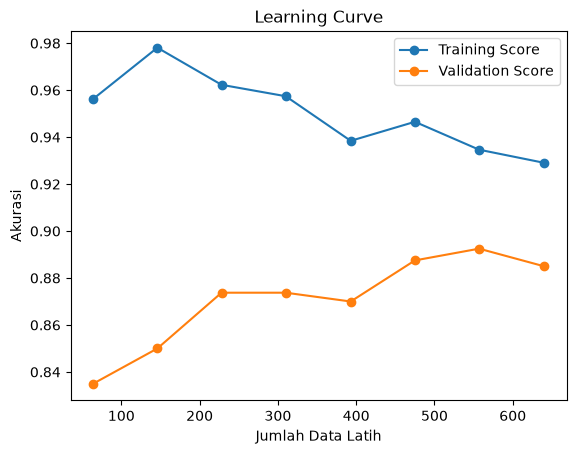

In [7]:
plt.plot(train_sizes,train_mean,'o-', label='Training Score')
plt.plot(train_sizes,val_mean,'o-', label='Validation Score')
plt.xlabel('Jumlah Data Latih')
plt.ylabel('Akurasi')
plt.title('Learning Curve')
plt.legend()
plt.show()

**Penjelasan outputnya:**
- Kurva validasi naik dari 0.835 ke 0.885 seiring bertambahnya data, sementara kurva train turun sedikit dari 0.956 ke 0.929 dan keduanya stabil di ujung kanan.
- Kedua kurva berakhir tinggi dan rapat dengan gap kecil, jadi diagnosisnya sama dengan sel sebelumnya: model seimbang dan siap dievaluasi lebih lanjut di test set.

### 2.12.1 Interpretasi (Modul Bab 2)

Apabila gap antara skor train dan validasi kecil dan keduanya berada pada level yang cukup tinggi, model dapat dikatakan memiliki keseimbangan bias-variance yang baik dan siap dievaluasi lebih lanjut pada test set. Apabila gap besar, pertimbangkan untuk menyederhanakan model (misalnya mengurangi max_depth) atau menambah data latih.

## 2.13 Latihan Praktikum (Modul Bab 2)

### Latihan 1 - Memetakan Proyek Nyata ke CRISP-DM (Modul Bab 2, bagian 2.13)

**Soal:** pilih studi kasus **prediksi churn pelanggan telekomunikasi** (dataset Telco Customer Churn). Tuliskan aktivitas konkret di 6 fase CRISP-DM.

Supaya pemetaannya konkret (bukan karangan), saya intip dulu datasetnya: `data/telco-customer-churn.csv`.

In [8]:
# Cuplikan data Telco Customer Churn untuk Latihan 1
churn = pd.read_csv("data/telco-customer-churn.csv")
print("Shape:", churn.shape)
print("\nDistribusi Churn (target):")
print(churn['Churn'].value_counts())
print((churn['Churn'].value_counts(normalize=True) * 100).round(2))
kosong = (churn['TotalCharges'].astype(str).str.strip() == '').sum()
print("\nBaris dengan TotalCharges kosong:", kosong)
print("\nRata-rata tenure (bulan) per status churn:")
print(churn.groupby('Churn')['tenure'].mean().round(1))
print("\nRata-rata MonthlyCharges per status churn:")
print(churn.groupby('Churn')['MonthlyCharges'].mean().round(1))
print("\nChurn rate per jenis kontrak:")
print(pd.crosstab(churn['Contract'], churn['Churn'], normalize='index').round(3))

Shape: (7043, 21)

Distribusi Churn (target):
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Baris dengan TotalCharges kosong: 11

Rata-rata tenure (bulan) per status churn:
Churn
No     37.6
Yes    18.0
Name: tenure, dtype: float64

Rata-rata MonthlyCharges per status churn:
Churn
No     61.3
Yes    74.4
Name: MonthlyCharges, dtype: float64

Churn rate per jenis kontrak:
Churn              No    Yes
Contract                    
Month-to-month  0.573  0.427
One year        0.887  0.113
Two year        0.972  0.028


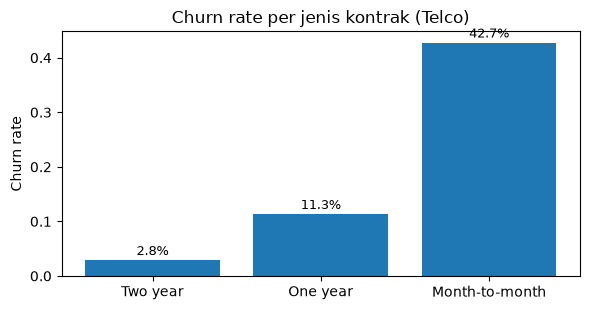

In [9]:
# Grafik: churn rate per jenis kontrak (sinyal bisnis terkuat di Latihan 1)
ct = pd.crosstab(churn['Contract'], churn['Churn'], normalize='index')['Yes'].sort_values()
plt.figure(figsize=(6, 3.2))
plt.bar(ct.index, ct.values)
plt.ylabel("Churn rate")
plt.title("Churn rate per jenis kontrak (Telco)")
for i, v in enumerate(ct.values):
    plt.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**Penjelasan grafiknya:** pelanggan kontrak **month-to-month** churn paling tinggi (sekitar 42,7%), sedangkan kontrak 1 tahun dan 2 tahun jauh lebih setia (11,3% dan 2,8%). Ini sinyal bisnis paling kuat: model churn harus memperhatikan `Contract`, dan tim retensi bisa menargetkan pelanggan bulanan dengan penawaran kontrak tahunan.

**Penjelasan outputnya:**
- Dataset: **7.043 pelanggan, 21 kolom**, targetnya `Churn` (Yes/No) dengan churn **1.869 pelanggan (26,54%)**: tidak seimbang, evaluasi tidak boleh mengandalkan akurasi mentah.
- Ada **11 baris** dengan `TotalCharges` kosong (terbaca string kosong, bukan NaN): data kotor yang harus dibersihkan di fase Data Preparation.
- Sinyal bisnis: pelanggan churn rata-rata baru **18,0 bulan** berlangganan (vs 37,6 yang bertahan) dengan tagihan bulanan **lebih mahal** (74,4 vs 61,3). Kontrak month-to-month churn **42,7%**, kontrak 2 tahun cuma **2,8%**.

**Jawaban: pemetaan ke 6 fase CRISP-DM:**

| Fase | Aktivitas konkret pada proyek churn |
|---|---|
| **1. Business Understanding** | Tujuan: menurunkan churn. Sukses bila model mengidentifikasi 80% calon churn dengan presisi yang bisa ditindaklanjuti tim retensi. Metrik utama: **recall** kelas churn (lebih baik salah alarm daripada kehilangan pelanggan). |
| **2. Data Understanding** | Eksplorasi 7.043 baris x 21 kolom: churn 26,54% (imbalance), 11 baris `TotalCharges` kosong, fitur kandidat kuat: `Contract` (month-to-month churn 42,7%), `tenure` (18,0 vs 37,6 bulan), `MonthlyCharges` (74,4 vs 61,3). |
| **3. Data Preparation** | Konversi `TotalCharges` ke numerik (11 baris kosong jadi NaN lalu imputasi median), one-hot encoding kolom kategorikal, scaling fitur numerik, **stratified split** 80/20 menjaga proporsi churn 26,54%. |
| **4. Modeling** | Baseline Logistic Regression, lalu Decision Tree dan Random Forest; tuning lewat learning curve + validasi silang ber-stratify; bandingkan F1/recall kelas churn, bukan sekadar akurasi. |
| **5. Evaluation** | Uji di test set yang belum tersentuh: confusion matrix dan precision-recall; validasi dengan tim bisnis, apakah daftar "pelanggan berisiko" masuk akal (misalnya didominasi kontrak bulanan + tenure pendek)? Kalau tidak, kembali ke fase 2/3. |
| **6. Deployment** | Deploy sebagai skor churn mingguan di dashboard CRM; skor tinggi otomatis masuk prioritas tim retensi (tawaran kontrak tahunan/diskon); monitor data drift, latih ulang kalau pola churn berubah. |

### Latihan 2 - Diagnosis Bias-Variance (Praktikum 2.7) (Modul Bab 2, bagian 2.13)

**Soal:** bandingkan learning curve untuk `max_depth` berbeda, lalu tulis diagnosis (underfitting/overfitting/seimbang) untuk setiap nilai.

In [10]:
# Bandingkan learning curve untuk max_depth berbeda
for depth in [1, 4, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    train_sizes,train_scores,val_scores = learning_curve( model,X_train,y_train,
        cv=5,train_sizes=np.linspace(0.1,1.0,6) )
    print(f"max_depth={depth}: train={train_scores.mean():.3f}, val={val_scores.mean():.3f}")
# Tuliskan diagnosis (underfitting/overfitting/seimbang) untuk setiap nilai max_depth.

max_depth=1: train=0.849, val=0.800
max_depth=4: train=0.952, val=0.866


max_depth=None: train=1.000, val=0.858


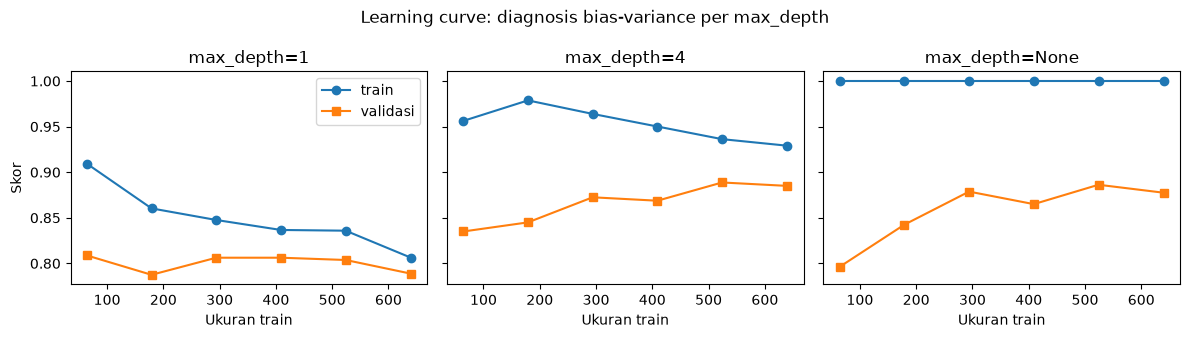

In [11]:
# Grafik learning curve untuk tiap max_depth (visualisasi diagnosis bias-variance)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, depth in zip(axes, [1, 4, None]):
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    ts, tr, va = learning_curve(m, X_train, y_train, cv=5,
                               train_sizes=np.linspace(0.1, 1.0, 6))
    ax.plot(ts, tr.mean(axis=1), 'o-', label="train")
    ax.plot(ts, va.mean(axis=1), 's-', label="validasi")
    ax.set_title(f"max_depth={depth}")
    ax.set_xlabel("Ukuran train")
axes[0].set_ylabel("Skor")
axes[0].legend()
fig.suptitle("Learning curve: diagnosis bias-variance per max_depth")
plt.tight_layout()
plt.show()

**Penjelasan grafiknya:** pada `max_depth=1` kedua kurva datar dan rendah (underfitting, bias tinggi); pada `max_depth=4` kedua kurva tinggi dan gap-nya wajar (seimbang); pada `max_depth=None` kurva train menempel di 1,000 sementara validasi tertinggal jauh di bawah (overfitting, variance tinggi).

**Jawaban: diagnosis tertulis tiap nilai `max_depth`:**
- **`max_depth=1` (underfitting):** skor train 0.849 dan validasi 0.800 sama-sama rendah dengan gap kecil, pohon sedalam 1 lapis terlalu sederhana untuk menangkap pola data (bias tinggi).
- **`max_depth=4` (seimbang):** skor train 0.952 dan validasi 0.866 keduanya tinggi dengan gap wajar, jadi ini konfigurasi paling seimbang di antara ketiganya.
- **`max_depth=None` (overfitting):** skor train 1.000 tapi validasi cuma 0.858 dengan gap 0.142, pohon tumbuh bebas sampai menghafal data latih (variance tinggi).

## Percobaan Mandiri

Tiga percobaan tambahan yang saya lakukan sendiri di data sintetis, tidak tumpang tindih dengan latihan.

### Percobaan Mandiri 1 - Split tanpa stratify vs dengan stratify

Saya bandingkan proporsi kelas di train/test kalau split dilakukan tanpa `stratify` versus dengan `stratify=y`.

In [12]:
# Split TANPA stratify
Xtr_ns, Xte_ns, ytr_ns, yte_ns = train_test_split(X, y, test_size=0.2, random_state=42)
print("Tanpa stratify  - train:", np.round(np.bincount(ytr_ns)/len(ytr_ns), 4),
      "| test:", np.round(np.bincount(yte_ns)/len(yte_ns), 4))
print("Dengan stratify - train:", np.round(np.bincount(y_train)/len(y_train), 4),
      "| test:", np.round(np.bincount(y_test)/len(y_test), 4))

Tanpa stratify  - train: [0.7887 0.2112] | test: [0.83 0.17]
Dengan stratify - train: [0.7975 0.2025] | test: [0.795 0.205]


**Kesimpulan:** tanpa stratify proporsi kelas 1 bergeser cukup jauh (train 21,1% vs test 17,0%), sedangkan dengan stratify proporsi terjaga (train 20,3% vs test 20,5%). Jadi stratify menjaga distribusi kelas tetap mewakili aslinya, penting supaya evaluasi di test set tidak bias karena kebetulan pembagian.

### Percobaan Mandiri 2 - Decision Tree vs Logistic Regression

Saya bandingkan akurasi test antara Decision Tree (`max_depth=4`) dan Logistic Regression pada data sintetis yang sama.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_train, y_train)
lr = LogisticRegression(max_iter=2000).fit(X_train, y_train)
print("Akurasi test DecisionTree     :", round(accuracy_score(y_test, dt.predict(X_test)), 3))
print("Akurasi test LogisticRegression:", round(accuracy_score(y_test, lr.predict(X_test)), 3))

Akurasi test DecisionTree     : 0.865
Akurasi test LogisticRegression: 0.84


**Kesimpulan:** Decision Tree (0.865) mengalahkan Logistic Regression (0.84) di data ini, wajar karena pola `make_classification` bersifat non-linear sehingga batas keputusan lurus dari regresi logistik kurang cocok.

### Percobaan Mandiri 3 - Logistic Regression dengan class_weight="balanced"

Dataset ini imbalance (kelas 1 cuma 20%), jadi saya bandingkan F1 kelas minoritas antara Logistic Regression default dan yang memakai `class_weight="balanced"`.

In [14]:
from sklearn.metrics import f1_score

lr_bal = LogisticRegression(max_iter=2000, class_weight="balanced").fit(X_train, y_train)
print("F1 kelas minoritas, LogisticRegression default   :", round(f1_score(y_test, lr.predict(X_test)), 3))
print("F1 kelas minoritas, LogisticRegression balanced :", round(f1_score(y_test, lr_bal.predict(X_test)), 3))

F1 kelas minoritas, LogisticRegression default   : 0.543
F1 kelas minoritas, LogisticRegression balanced : 0.569


**Kesimpulan:** memberi `class_weight="balanced"` menaikkan F1 kelas minoritas dari 0.543 ke 0.569, jadi model sedikit lebih adil dalam mengenali kelas yang jarang muncul tanpa mengorbankan model secara keseluruhan.

## Kesimpulan Bab 2

1. CRISP-DM memberi struktur 6 fase (Business Understanding sampai Deployment) yang iteratif, dan pemetaannya ke proyek churn Telco menunjukkan tiap fase punya aktivitas konkret.
2. Stratified split menjaga proporsi kelas tetap sama di train dan test, penting untuk dataset tidak seimbang seperti data sintetis ini.
3. Learning curve Decision Tree `max_depth=4` menunjukkan skor train 0.929 dan validasi 0.885 dengan gap kecil 0.044: model seimbang, tidak overfitting.
4. Perbandingan `max_depth` membuktikan bias-variance tradeoff: `max_depth=1` underfitting, `None` overfitting, dan `4` yang paling seimbang.
5. Pada data imbalance, `class_weight="balanced"` membantu model mengenali kelas minoritas (F1 naik dari 0.543 ke 0.569).